In [2]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading The Data csv File To A pandas DataFame
customer_data=pd.read_csv(r"F:\DS & DA Projects\real-time projects\self learning ds\kaggle\Customer Segmentation using K-Means Clustering\Data\Mall_Customers.csv")
customer_data


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
# First Five Rows In The DataFame
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Last Five Rows IN The DataFrame
customer_data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [6]:
# Finding The Number Of Rows And Columns
customer_data.shape

(200, 5)

In [7]:
#Getting Some Information About Dataset
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [8]:
# The Show Minimun Sttistical Report In The DataFrame
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
# To See The Columns Names
customer_data.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

In [10]:
# Checking For Missing Values
customer_data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Choosing The Annual income Column And Spending Score Column

In [11]:
# select ferue for Clustering
x=customer_data[['Annual Income (k$)','Spending Score (1-100)' ]]
print(x)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


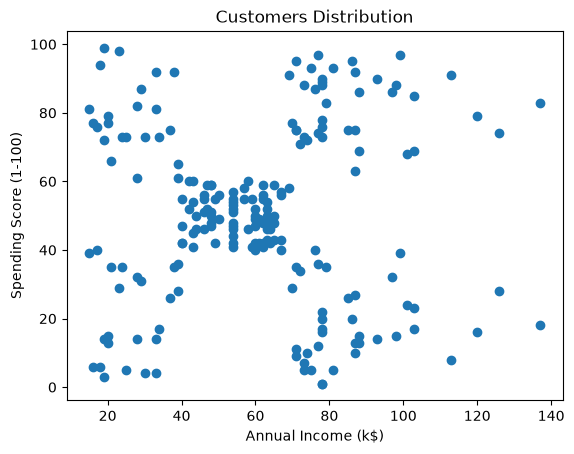

In [12]:
# Select The Data (Before Clustering)

plt.Figure(figsize=(7,5))
plt.scatter(x.iloc[:,0], x.iloc[:,1])
plt.title("Customers Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

Choosing The Number Of Cluster

WCSS--Within Cluster Sum Of Squares

In [13]:
# Finding WCSS Values For Different Number Of Clusters

WCSS=[] #inetia

for i in range(1,11):
    Kmeans_model=KMeans( n_clusters=i, init='k-means++', random_state=42 )
    Kmeans_model.fit(x)
    WCSS.append(Kmeans_model.inertia_)

# n_clyster=k-> the model will from k group(clusters) in the data
# the values of kk come from the loop:
# Lowewr inertia = better clustering
# Always decreases as k inceases -> not sufficient alone



In [14]:
print("WCSS:",WCSS)

print("Length of WCSS:", len(WCSS))

WCSS: [269981.28, 183653.3289473684, 106348.37306211119, 73880.64496247195, 44448.45544793371, 40825.16946386946, 33642.579220779226, 26686.83778518778, 24766.471609793443, 23103.122085983916]
Length of WCSS: 10


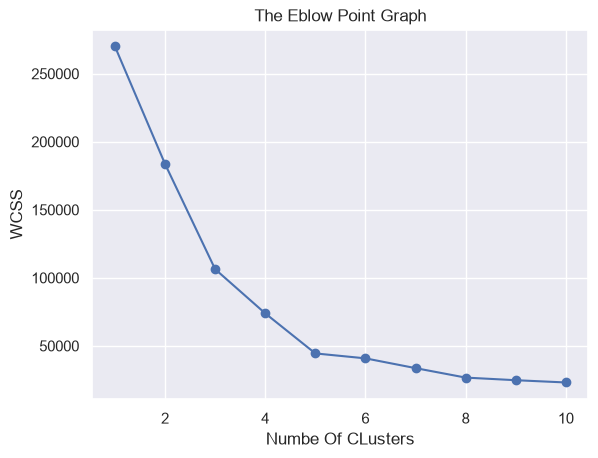

In [15]:
# plot An Elbow Graph
plt.Figure(figsize=(8,5))

sns.set()
plt.plot(range(1,11), WCSS, marker='o')
plt.title("The Eblow Point Graph")
plt.xlabel("Numbe Of CLusters")
plt.ylabel("WCSS")
plt.show()

Optimum NUmber of Clusters=5

Training The K-means Clustering Model

In [16]:
Kmeans_model=KMeans(n_clusters=5, random_state=0)

# Return a label for each data point based on their cluster
# 
y_kmeans=Kmeans_model.fit_predict(x)
print(y_kmeans)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


In [17]:
# apply k-Mens With Optionl K
customer_data["Cluster"]=y_kmeans
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


Visualizing all the Cluster

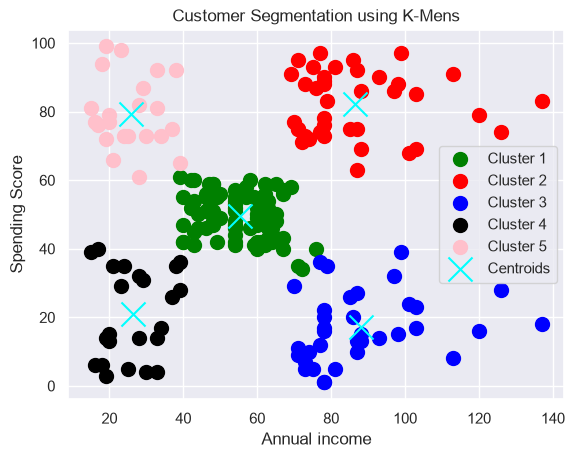

In [18]:
# plotting all the CLusters and their Centroids

plt.Figure(figsize=(8,6))

# s contols the size of the ponts (markers) in the sctter plot.
# it makes cluster points large and easy to see
# s =100 -> ech data point hs n aea of 100

plt.scatter(x[y_kmeans==0].iloc[:,0],
            x[y_kmeans==0].iloc[:,1], s=100, c="green", label="Cluster 1")
plt.scatter(x[y_kmeans==1].iloc[:,0], 
            x[y_kmeans==1].iloc[:,1], s=100, c="red", label="Cluster 2")
plt.scatter(x[y_kmeans==2].iloc[:,0], 
            x[y_kmeans==2].iloc[:,1], s=100, c="blue", label="Cluster 3")
plt.scatter(x[y_kmeans==3].iloc[:,0], 
            x[y_kmeans==3].iloc[:,1], s=100, c="black", label="Cluster 4")
plt.scatter(x[y_kmeans==4].iloc[:,0], 
            x[y_kmeans==4].iloc[:,1], s=100, c="pink", label="Cluster 5")

#plot the centoids
plt.scatter(Kmeans_model.cluster_centers_[:,0], 
            Kmeans_model.cluster_centers_[:,1], 
            s=300,
            c="cyan",
            marker='x',
            label="Centroids")
plt.title("Customer Segmentation using K-Mens")
plt.xlabel("Annual income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()



Imterpretationof Clusters

| Cluster                           |Customer Type
|-----------------------------------|------------------
|High income, High Spending         |Premium Customers
|High Income, Low Spending          |Creful Customers
|Low income, High Spending          |Impulsive Customers
|Low income, Low Spending           |Low Values Customer
|Medium income, Medium Spending     |veage Customers


In [19]:
# (Optionl) Cluster With ge Included
X1=customer_data[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
from sklearn.preprocessing import StandardScaler
model=StandardScaler()
X1_scaled=model.fit_transform(X1)

Kmeans1=KMeans(n_clusters=5, random_state=42)
customer_data['Cluster_3D' ]=Kmeans1.fit_predict(X1_scaled)
print(customer_data['Cluster_3D'].shape)



(200,)


In [20]:
# model Evaluation (Accuarcy)

from sklearn.metrics import silhouette_score

score=silhouette_score(x, y_kmeans)
print("Silhouette Score:", score)

# Range : -1 t0 +!

Silhouette Score: 0.553931997444648


|Score | Meaning
|----- |-----------------
|+1    | Excellent Clustering
|0     | Overlapping Clustring
|-1    | Wrong Clustering

In [21]:
import pickle
import os
# create a directory to save the model if it doesn't exist
os.makedirs("../model", exist_ok=True) 

with open("../model/kmeans_customer_segmentation.pkl", "wb") as f:
    pickle.dump(Kmeans_model, f)

In [22]:
# save feature names
os.makedirs("../model", exist_ok=True)

with open("../model/cluster_features.pkl", "wb") as f:
    pickle.dump(x.columns.tolist(), f)